# MNIST Classifier (Original Dataspace) + Classifying DDPM Samples

Trains a classifier on **original MNIST** pixels (in **[0,1]** with the standard MNIST normalization.
It also includes helper code to classify samples from your diffusion notebook after `undo_precond()`.


In [ ]:
# import math
# import random
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import DataLoader
# from torchvision import datasets, transforms
# from torchvision.utils import make_grid
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# import sys, os

# print(sys.executable)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("device:", device)
# if torch.cuda.is_available():
#     print(f"GPU Name: {torch.cuda.get_device_name(0)}")
#     print(f"Allocated: {round(torch.cuda.memory_allocated(0)/1024**3,1)} GB")


/home/hoffmanp/diff_env/.venv/bin/python
device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB


In [ ]:
# def set_seed(seed: int):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
#     print("Seed set to:", seed)

# SEED = 2026
# set_seed(SEED)


Seed set to: 2026


## 1) Choose the classifier input space

### Recommended (default): **[0,1]** with standard MNIST normalization
- Train on `ToTensor()` output in **[0,1]** and apply `Normalize(mean=0.1307, std=0.3081)`.
- To classify diffusion samples that you currently have in **[-1,1]**, convert via `(x+1)/2` then apply the same normalization.

In [ ]:
# # -----------------------------
# # Config
# # -----------------------------
# IMG_SIZE = 28
# BATCH_SIZE = 64

# # Choose:
# #   INPUT_SPACE = "01_norm"  -> [0,1] + standard MNIST Normalize(mean,std)  (recommended)
# #   INPUT_SPACE = "m11"      -> [-1,1] (no further normalize)
# INPUT_SPACE = "01_norm"

# MNIST_MEAN = 0.1307
# MNIST_STD  = 0.3081

# if INPUT_SPACE == "01_norm":
#     tfm = transforms.Compose([
#         transforms.ToTensor(),  # [0,1]
#         transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
#     ])
# else:
#     raise ValueError(f"Unknown INPUT_SPACE: {INPUT_SPACE}")

# def ddpm_raw_to_clf_input(x_raw_m11: torch.Tensor) -> torch.Tensor:
#     """
#     Convert x from diffusion output space (assumed [-1,1]) into the classifier input space.
#     x_raw_m11: [B,1,28,28] in [-1,1]
#     returns: [B,1,28,28] in the SAME space the classifier expects.
#     In particular, subtract MNIST_MEAN and divide by MNIST_STD just like we did on for classifier training!
#     """
#     x_raw_m11 = x_raw_m11.clamp(-1, 1)

#     if INPUT_SPACE == "01_norm":
#         x01 = (x_raw_m11 + 1) / 2  # [0,1]
#         x = (x01 - MNIST_MEAN) / MNIST_STD
#         return x
#     else:
#         raise ValueError("Bad INPUT_SPACE")


In [ ]:
# # -----------------------------
# # Data: ORIGINAL MNIST (no preconditioning other than normalizing in transform=tfm)
# # -----------------------------
# train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
# test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

# train_loader = DataLoader(
#     train_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     num_workers=0,
#     pin_memory=(device.type == "cuda"),
#     drop_last=False,
# )
# test_loader = DataLoader(
#     test_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=(device.type == "cuda"),
#     drop_last=False,
# )


In [ ]:
# class MNISTCNN(nn.Module):
#     """
#     Input:  [B,1,28,28] in the space defined by INPUT_SPACE.
#     Output: logits [B,10]
#     """
#     def __init__(self):
#         super().__init__()
#         self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
#         self.fc1 = nn.Linear(128 * 7 * 7, 256)
#         self.fc2 = nn.Linear(256, 10)
#         self.drop = nn.Dropout(0.25)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         x = F.relu(self.conv1(x))
#         x = F.max_pool2d(F.relu(self.conv2(x)), 2)  # 28 -> 14
#         x = F.max_pool2d(F.relu(self.conv3(x)), 2)  # 14 -> 7
#         x = self.drop(x)
#         x = x.flatten(1)
#         x = F.relu(self.fc1(x))
#         x = self.drop(x)
#         return self.fc2(x)

# clf = MNISTCNN().to(device)
# clf_opt = torch.optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-4)


In [ ]:
# @torch.no_grad()
# def eval_acc(model: nn.Module, loader: DataLoader) -> float:
#     model.eval()
#     correct, total = 0, 0
#     for x, y in loader:
#         x = x.to(device, non_blocking=(device.type == "cuda"))
#         y = y.to(device, non_blocking=(device.type == "cuda"))
#         pred = model(x).argmax(dim=1)
#         correct += (pred == y).sum().item()
#         total += y.numel()
#     return 100.0 * correct / max(total, 1)


In [ ]:
# # -----------------------------
# # Train
# # -----------------------------
# CLF_EPOCHS = 5

# for epoch in range(1, CLF_EPOCHS + 1):
#     clf.train()
#     pbar = tqdm(train_loader, desc=f"[CLF] Epoch {epoch}/{CLF_EPOCHS}", leave=True)
#     ema = None

#     for x, y in pbar:
#         x = x.to(device, non_blocking=(device.type == "cuda"))
#         y = y.to(device, non_blocking=(device.type == "cuda"))

#         logits = clf(x)
#         loss = F.cross_entropy(logits, y)

#         clf_opt.zero_grad(set_to_none=True)
#         loss.backward()
#         clf_opt.step()

#         ema = loss.item() if ema is None else (0.95 * ema + 0.05 * loss.item())
#         pbar.set_postfix(loss=f"{ema:.4f}")

#     acc = eval_acc(clf, test_loader)
#     print(f"[CLF] Epoch {epoch}: loss={ema:.4f} | test_acc={acc:.2f}%")


[CLF] Epoch 1/5: 100%|██████████| 938/938 [00:06<00:00, 150.86it/s, loss=0.0751]


[CLF] Epoch 1: loss=0.0751 | test_acc=98.66%


[CLF] Epoch 2/5: 100%|██████████| 938/938 [00:05<00:00, 170.64it/s, loss=0.0476]


[CLF] Epoch 2: loss=0.0476 | test_acc=99.20%


[CLF] Epoch 3/5: 100%|██████████| 938/938 [00:05<00:00, 160.12it/s, loss=0.0507]


[CLF] Epoch 3: loss=0.0507 | test_acc=99.03%


[CLF] Epoch 4/5: 100%|██████████| 938/938 [00:05<00:00, 169.67it/s, loss=0.0348]


[CLF] Epoch 4: loss=0.0348 | test_acc=99.32%


[CLF] Epoch 5/5: 100%|██████████| 938/938 [00:05<00:00, 168.61it/s, loss=0.0245]


[CLF] Epoch 5: loss=0.0245 | test_acc=99.24%


## 3) Classify diffusion samples

In your diffusion notebook, after sampling, save **`ddpm_samples_raw`** (the tensor in **[-1,1]** after `undo_precond()`):

```python
torch.save(ddpm_samples_raw.cpu(), "ddpm_samples_raw.pt")
```

Then load and classify them here.


In [ ]:
# # -----------------------------
# # Load DDPM samples (produced by your diffusion notebook)
# # Expected file: ddpm_samples_raw.pt containing [B,1,28,28] in [-1,1].
# # -----------------------------
# ddpm_samples_path = "./ddpm_samples_raw.pt"  # change if needed

# if os.path.exists(ddpm_samples_path):
#     ddpm_samples_raw = torch.load(ddpm_samples_path, map_location="cpu")  # these are the output samples in [-1,1]
#     print("Loaded ddpm_samples_raw:", tuple(ddpm_samples_raw.shape), ddpm_samples_raw.dtype)
# else:
#     ddpm_samples_raw = None
#     print(
#         f"File not found: {ddpm_samples_path}\n"
#         "Run the diffusion notebook and save it with:\n"
#         "  torch.save(ddpm_samples_raw.cpu(), './ddpm_samples_raw.pt')"
#     )


Loaded ddpm_samples_raw: (25, 1, 28, 28) torch.float32


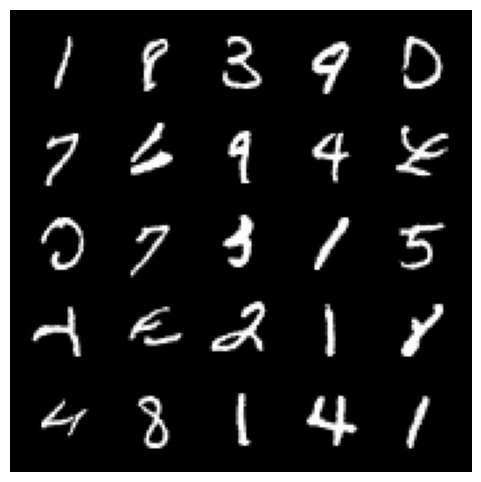

[DDPM->CLF] 1st row preds: [1, 8, 3, 9, 0]
[DDPM->CLF] 1st row preds: [1, 8, 3, 9, 0]
[DDPM->CLF] 2nd row preds: [7, 6, 9, 4, 8]
[DDPM->CLF] 3rd row preds: [0, 7, 3, 1, 5]
[DDPM->CLF] 4th row preds: [4, 2, 2, 1, 8]
[DDPM->CLF] 5th row preds: [4, 8, 1, 4, 1]
[DDPM->CLF] confidences: [1.0, 1.0, 1.0, 0.99, 1.0]
[DDPM->CLF] confidences: [1.0, 0.95, 1.0, 1.0, 0.89]
[DDPM->CLF] confidences: [1.0, 1.0, 0.99, 1.0, 1.0]
[DDPM->CLF] confidences: [1.0, 0.64, 1.0, 1.0, 1.0]
[DDPM->CLF] confidences: [1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
# @torch.no_grad()
# def classify_and_show(ddpm_samples_raw: torch.Tensor, nrow: int = 5):
#     """
#     ddpm_samples_raw: [B,1,28,28] in [-1,1]
#     """
#     clf.eval()

#     # pull in the ddpm_raw samples, convert them from [-1,1] to [0,1], then MNIST normalize
#     x_clf = ddpm_raw_to_clf_input(ddpm_samples_raw).to(device)
    
#     logits = clf(x_clf)
#     probs  = torch.softmax(logits, dim=1)
#     preds = logits.argmax(dim=1).cpu()

#     # Visualization: show images in [0,1] regardless of classifier space
#     vis = (ddpm_samples_raw.clamp(-1, 1) + 1) / 2
#     grid = make_grid(vis, nrow=nrow, padding=6)
#     plt.figure(figsize=(6, 6))
#     plt.axis("off")
#     plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
#     plt.show()


#     print("[DDPM->CLF] 1st row preds:", preds[0:5].detach().cpu().tolist())
#     print("[DDPM->CLF] 1st row preds:", preds[0:5].detach().cpu().tolist())
#     print("[DDPM->CLF] 2nd row preds:", preds[5:10].detach().cpu().tolist())
#     print("[DDPM->CLF] 3rd row preds:", preds[10:15].detach().cpu().tolist())
#     print("[DDPM->CLF] 4th row preds:", preds[15:20].detach().cpu().tolist())
#     print("[DDPM->CLF] 5th row preds:", preds[20:25].detach().cpu().tolist())

#     print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[0:5].detach().cpu().tolist()])
#     print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[5:10].detach().cpu().tolist()])
#     print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[10:15].detach().cpu().tolist()])
#     print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[15:20].detach().cpu().tolist()])
#     print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[20:25].detach().cpu().tolist()])



# if ddpm_samples_raw is not None:
#     _ = classify_and_show(ddpm_samples_raw[:25], nrow=5)


## 4) What to change in your diffusion sampling code

If you keep this notebook's default `INPUT_SPACE='01_norm'`:

- Keep your existing `ddpm_samples_raw = undo_precond(...).clamp(-1,1)`.
- For classification, convert to `[0,1]` and normalize with MNIST mean/std:

```python
ddpm_samples_01 = (ddpm_samples_raw + 1) / 2
ddpm_samples_clf = (ddpm_samples_01 - 0.1307) / 0.3081
pred = clf(ddpm_samples_clf.to(device)).argmax(1)
```

In [ ]:

import math
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm

print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Allocated: {round(torch.cuda.memory_allocated(0) / 1024**3, 1)} GB")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("Seed set to:", seed)


SEED = 2026
set_seed(SEED)

IMG_SIZE = 28
D = IMG_SIZE * IMG_SIZE


# ============================================================
# Part B: classifier training
# ============================================================

# Assumes Part A has already been run so imports/device/set_seed exist.
set_seed(SEED)

BATCH_SIZE = 64

# Default preserved from your original notebook.
# You can switch to "01" if you want a classifier trained on raw [0,1] with no extra normalization.
INPUT_SPACE = "01_norm"

MNIST_MEAN = 0.1307
MNIST_STD = 0.3081


def get_classifier_transform(input_space: str = "01_norm"):
    if input_space == "01_norm":
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
        ])
    if input_space == "01":
        return transforms.ToTensor()
    raise ValueError(f"Unknown INPUT_SPACE: {input_space}")


def ddpm_raw_to_clf_input(x_raw_m11: torch.Tensor, input_space: str = "01_norm") -> torch.Tensor:
    """
    Convert DDPM outputs from original image space [-1,1] into the classifier input space.
    """
    x_raw_m11 = x_raw_m11.clamp(-1, 1)
    x01 = (x_raw_m11 + 1.0) / 2.0

    if input_space == "01_norm":
        return (x01 - MNIST_MEAN) / MNIST_STD
    if input_space == "01":
        return x01
    raise ValueError(f"Unknown INPUT_SPACE: {input_space}")


class MNISTCNN(nn.Module):
    """
    Same classifier architecture as your original notebook.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)
        self.drop = nn.Dropout(0.25)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)   # 28 -> 14
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)   # 14 -> 7
        x = self.drop(x)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


@torch.no_grad()
def eval_acc(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=(device.type == "cuda"))
        y = y.to(device, non_blocking=(device.type == "cuda"))
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total


def train_classifier(
    root: str = "./data",
    batch_size: int = 64,
    epochs: int = 5,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    input_space: str = INPUT_SPACE,
    checkpoint_path: str | None = None,
):
    tfm = get_classifier_transform(input_space=input_space)

    train_ds = datasets.MNIST(root=root, train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root=root, train=False, download=True, transform=tfm)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )

    clf = MNISTCNN().to(device)
    optimizer = torch.optim.AdamW(clf.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        clf.train()
        pbar = tqdm(train_loader, desc=f"[CLF] Epoch {epoch}/{epochs}", leave=True)
        ema = None

        for x, y in pbar:
            x = x.to(device, non_blocking=(device.type == "cuda"))
            y = y.to(device, non_blocking=(device.type == "cuda"))

            logits = clf(x)
            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            ema = loss.item() if ema is None else (0.95 * ema + 0.05 * loss.item())
            pbar.set_postfix(loss=f"{ema:.4f}")

        acc = eval_acc(clf, test_loader)
        print(f"[CLF] Epoch {epoch}: loss={ema:.4f} | test_acc={acc:.2f}%")

    clf_artifacts = {
        "model": clf,
        "config": {
            "root": root,
            "batch_size": batch_size,
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay,
            "input_space": input_space,
        },
    }

    if checkpoint_path is not None:
        save_classifier_checkpoint(clf_artifacts, checkpoint_path)

    return clf_artifacts


def save_classifier_checkpoint(clf_artifacts: dict, path: str):
    ckpt = {
        "config": clf_artifacts["config"],
        "model_state_dict": clf_artifacts["model"].state_dict(),
    }
    torch.save(ckpt, path)
    print(f"Saved classifier checkpoint to {path}")


def load_classifier_checkpoint(path: str, device: torch.device = device):
    ckpt = torch.load(path, map_location=device)

    clf = MNISTCNN().to(device)
    clf.load_state_dict(ckpt["model_state_dict"])
    clf.eval()

    clf_artifacts = {
        "model": clf,
        "config": ckpt["config"],
    }
    print(f"Loaded classifier checkpoint from {path}")
    return clf_artifacts


@torch.no_grad()
def classify_ddpm_raw(clf_artifacts: dict, x_raw_m11: torch.Tensor):
    """
    Classify reconstructed DDPM outputs after converting them to classifier input space.
    Returns:
      preds: [B]
      conf:  [B] max softmax confidence
      probs: [B,10]
    """
    clf = clf_artifacts["model"]
    input_space = clf_artifacts["config"]["input_space"]

    clf.eval()
    x_clf = ddpm_raw_to_clf_input(x_raw_m11, input_space=input_space).to(device)
    logits = clf(x_clf)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    conf = probs.max(dim=1).values
    return preds, conf, probs


@torch.no_grad()
def show_ddpm_classifications(clf_artifacts: dict, ddpm_samples_raw: torch.Tensor, nrow: int = 5):
    preds, conf, _ = classify_ddpm_raw(clf_artifacts, ddpm_samples_raw)

    vis = (ddpm_samples_raw.clamp(-1, 1) + 1.0) / 2.0
    grid = make_grid(vis.cpu(), nrow=nrow, padding=6)

    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.show()

    print("preds:", preds.detach().cpu().tolist())
    print("conf :", [round(x, 3) for x in conf.detach().cpu().tolist()])


2.9.1+cu128
device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB
Seed set to: 2026
Seed set to: 2026


[CLF] Epoch 1/5: 100%|██████████| 938/938 [00:05<00:00, 157.41it/s, loss=0.0751]


[CLF] Epoch 1: loss=0.0751 | test_acc=98.66%


[CLF] Epoch 2/5: 100%|██████████| 938/938 [00:05<00:00, 164.60it/s, loss=0.0476]


[CLF] Epoch 2: loss=0.0476 | test_acc=99.20%


[CLF] Epoch 3/5: 100%|██████████| 938/938 [00:05<00:00, 170.61it/s, loss=0.0507]


[CLF] Epoch 3: loss=0.0507 | test_acc=99.03%


[CLF] Epoch 4/5: 100%|██████████| 938/938 [00:05<00:00, 172.31it/s, loss=0.0348]


[CLF] Epoch 4: loss=0.0348 | test_acc=99.32%


[CLF] Epoch 5/5: 100%|██████████| 938/938 [00:05<00:00, 165.61it/s, loss=0.0245]


[CLF] Epoch 5: loss=0.0245 | test_acc=99.24%
Saved classifier checkpoint to mnist_classifier.pt


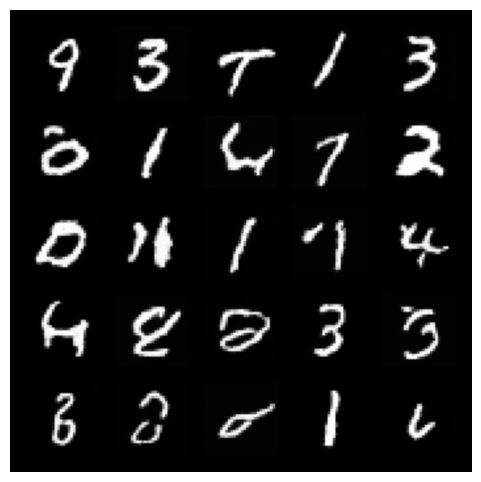

preds: [9, 3, 7, 1, 3, 2, 1, 6, 7, 2, 0, 4, 1, 7, 4, 4, 8, 2, 3, 3, 3, 2, 2, 1, 6]
conf : [0.975, 1.0, 1.0, 1.0, 1.0, 0.643, 1.0, 0.988, 1.0, 1.0, 1.0, 0.998, 1.0, 0.891, 1.0, 0.962, 1.0, 0.996, 1.0, 0.917, 0.857, 1.0, 0.695, 1.0, 0.837]


In [2]:

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
clf_artifacts = train_classifier(
    input_space="01_norm",
    checkpoint_path="mnist_classifier.pt",
)

ddpm_samples_raw = torch.load("ddpm_samples_raw.pt", map_location=device)
show_ddpm_classifications(clf_artifacts, ddpm_samples_raw[:25], nrow=5)